Practica con moire

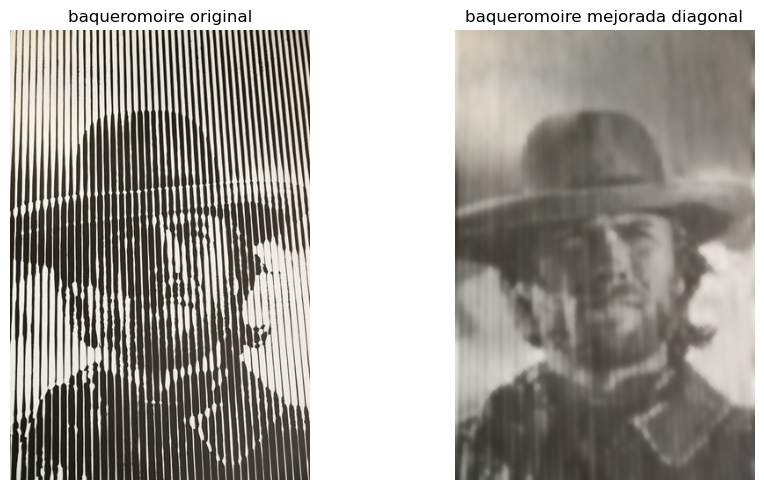

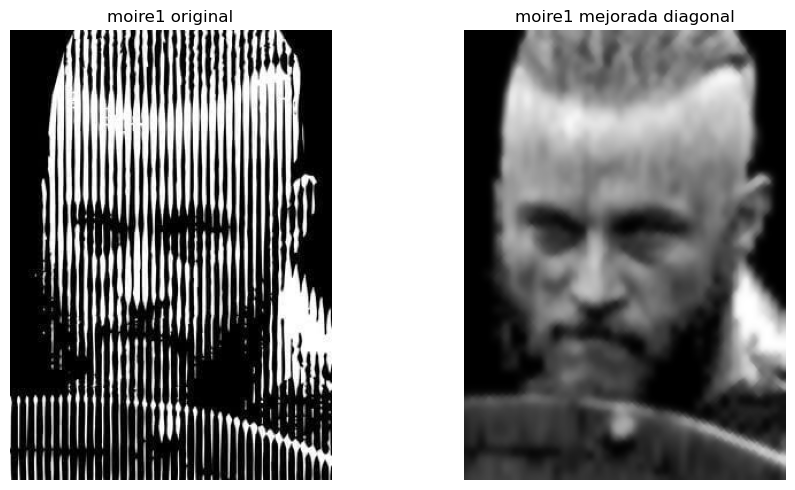

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def crear_kernel_diagonal(tam=7):
    k = np.eye(tam, dtype=np.float32)
    return k / np.sum(k)


def crear_kernel_diagonal_inversa(tam=7):
    k = np.fliplr(np.eye(tam, dtype=np.float32))
    return k / np.sum(k)


def reducir_moire_diagonal(imagen, tam=7, pasadas=2):
    kernel_d = crear_kernel_diagonal(tam)
    kernel_di = crear_kernel_diagonal_inversa(tam)

    salida = imagen.copy()
    for _ in range(pasadas):
        diag = cv2.filter2D(salida, -1, kernel_d)
        diag_inv = cv2.filter2D(salida, -1, kernel_di)
        salida = cv2.addWeighted(diag, 0.5, diag_inv, 0.5, 0)

    salida = cv2.bilateralFilter(salida, d=7, sigmaColor=45, sigmaSpace=45)
    return salida


def mostrar_moire_mejorado(ruta_imagen, titulo):
    img_color = cv2.imread(ruta_imagen)
    if img_color is None:
        raise ValueError(f"No se pudo cargar {ruta_imagen}")

    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    color_mejorada = reducir_moire_diagonal(img_rgb, tam=7, pasadas=2)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"{titulo} original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(color_mejorada)
    plt.title(f"{titulo} mejorada diagonal")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_moire_mejorado("baqueromoire.jpeg", "baqueromoire")
mostrar_moire_mejorado("moire1.jpeg", "moire1")

## Informe: Reduccion del efecto moire con convolucion diagonal

Se aplico una estrategia de filtrado orientado para contrarrestar las lineas periodicas del moire en `baqueromoire.jpeg` y `moire1.jpeg`.

1. **Carga y conversion de color**
   - La imagen se carga con OpenCV y se convierte de BGR a RGB para visualizar correctamente en Matplotlib.

2. **Convolucion diagonal principal**
   - Se construyo un kernel diagonal de tamano 7x7 usando la diagonal principal.
   - Este kernel promedia informacion a lo largo de esa direccion y reduce variaciones rapidas tipo franjas.

3. **Convolucion diagonal inversa**
   - Se uso un segundo kernel en diagonal opuesta.
   - Combinar ambas diagonales ayuda a suavizar patrones de interferencia con distintas orientaciones.

4. **Combinacion por pasadas**
   - En cada pasada se calcula salida con diagonal y diagonal inversa.
   - Luego se combinan ambas con pesos 0.5 y 0.5 (`addWeighted`).
   - Se repiten 2 pasadas para aumentar la atenuacion del moire.

5. **Suavizado bilateral final**
   - Se aplica `bilateralFilter` para reducir ruido de alta frecuencia manteniendo mejor los bordes globales.

### Resultado
- Se reduce visiblemente el patron de lineas del moire en ambas imagenes.
- Como efecto secundario, hay perdida moderada de detalle fino, lo cual es normal en procesos de supresion de interferencia periodica.

### Parametros usados
- Tamano de kernel diagonal: `tam=7`
- Pasadas de combinacion: `pasadas=2`
- Bilateral: `d=7`, `sigmaColor=45`, `sigmaSpace=45`

Si se desea mas nitidez, se puede bajar el bilateral (por ejemplo `sigmaColor=30`, `sigmaSpace=30`) o aplicar un enfoque suave al final.